## Hence in the last assignemnt we already did the labelling and all the EDA. For model building we need to ensure that file namings are same for usage with metadata so performing few steps again with Gaussian Blur, Histogram Equalization and Intensity thresholds and train & test data split.

## Aravind's Contribution

Class Distribution:
drink: 15670
food: 108047
inside: 56030
menu: 1678
outside: 18569


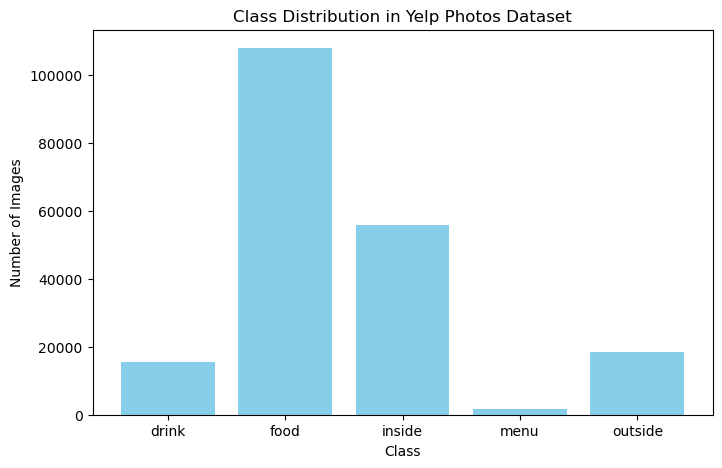

In [5]:
import os
import matplotlib.pyplot as plt

base_dir = r'./labeled_photos'  

class_counts = {}

# Loop through each class folder
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if os.path.isdir(class_path):
        count = len([img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[class_name] = count

# Print results
print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Yelp Photos Dataset')
plt.show()

## Seting up paths and load metadata

## Gaussian Blur, Histogram Equalization, Intensity Threshold

- Randomly sample enough original images from each class so that after augmentation (original + 3 variants) we will have close to 5,000 images.
- Only augmenting the sampled originals.
- No need to process every image in huge classes!

In [25]:
import os
import cv2
import random
import math
from tqdm import tqdm
import pandas as pd

# Parameters
input_dir = r'./labeled_photos'
output_dir = r'./balanced_photos_5000'
metadata_json = r'./photos.json'
target_count = 5000

os.makedirs(output_dir, exist_ok=True)

# Load metadata
metadata_df = pd.read_json(metadata_json, lines=True)
metadata_df['filename'] = metadata_df['photo_id'] + '.jpg'
metadata_df.set_index('filename', inplace=True)

augmented_meta_rows = []

for cls in os.listdir(input_dir):
    in_class_dir = os.path.join(input_dir, cls)
    out_class_dir = os.path.join(output_dir, cls)
    os.makedirs(out_class_dir, exist_ok=True)

    all_imgs = [img for img in os.listdir(in_class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Calculate how many originals needed for 5k total after 4 augmentations per image
    sample_size = math.ceil(target_count / 4) if len(all_imgs) > math.ceil(target_count / 4) else len(all_imgs)
    sampled_imgs = random.sample(all_imgs, sample_size) if len(all_imgs) > sample_size else all_imgs

    current_count = 0

    for img_name in tqdm(sampled_imgs, desc=f"Augmenting {cls}"):
        img_path = os.path.join(in_class_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        # 1. Save original
        if current_count < target_count:
            out_img_name = f"{os.path.splitext(img_name)[0]}.jpg"
            cv2.imwrite(os.path.join(out_class_dir, out_img_name), img)
            # Metadata for original
            try:
                orig_row = metadata_df.loc[img_name].copy()
                new_row = orig_row.copy()
                new_row.name = out_img_name
                augmented_meta_rows.append(new_row)
            except KeyError:
                pass
            current_count += 1

        # 2. Gaussian Blur
        if current_count < target_count:
            blur = cv2.GaussianBlur(img, (5,5), 0)
            blur_name = f"{os.path.splitext(img_name)[0]}_blur.jpg"
            cv2.imwrite(os.path.join(out_class_dir, blur_name), blur)
            try:
                orig_row = metadata_df.loc[img_name].copy()
                new_row_blur = orig_row.copy()
                new_row_blur.name = blur_name
                augmented_meta_rows.append(new_row_blur)
            except KeyError:
                pass
            current_count += 1

        # 3. Histogram Equalization
        if current_count < target_count:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            hist = cv2.equalizeHist(gray)
            hist_col = cv2.cvtColor(hist, cv2.COLOR_GRAY2BGR)
            hist_name = f"{os.path.splitext(img_name)[0]}_hist.jpg"
            cv2.imwrite(os.path.join(out_class_dir, hist_name), hist_col)
            try:
                orig_row = metadata_df.loc[img_name].copy()
                new_row_hist = orig_row.copy()
                new_row_hist.name = hist_name
                augmented_meta_rows.append(new_row_hist)
            except KeyError:
                pass
            current_count += 1

        # 4. Intensity Threshold
        if current_count < target_count:
            _, thresh = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
            thresh_col = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
            thresh_name = f"{os.path.splitext(img_name)[0]}_thresh.jpg"
            cv2.imwrite(os.path.join(out_class_dir, thresh_name), thresh_col)
            try:
                orig_row = metadata_df.loc[img_name].copy()
                new_row_thresh = orig_row.copy()
                new_row_thresh.name = thresh_name
                augmented_meta_rows.append(new_row_thresh)
            except KeyError:
                pass
            current_count += 1

        # Stop if  hit 5000
        if current_count >= target_count:
            break

Augmenting outside: 100%|█████████████████████████████████████████████████████████▉| 1249/1250 [01:14<00:00, 16.75it/s]


## Saving metadata for future use

In [32]:
# Make DataFrame, reset index so filename is a column
if augmented_meta_rows:
    balanced_meta_df = pd.DataFrame(augmented_meta_rows)
    balanced_meta_df = balanced_meta_df.reset_index(drop=True)
    balanced_meta_df.to_csv(os.path.join(output_dir, './balanced_photos_metadata.csv'), index=False)
    print("Balanced metadata saved!")
else:
    print("No metadata rows found!")

Balanced metadata saved!


## Display Random Images From Each Class (Including Augmentations)

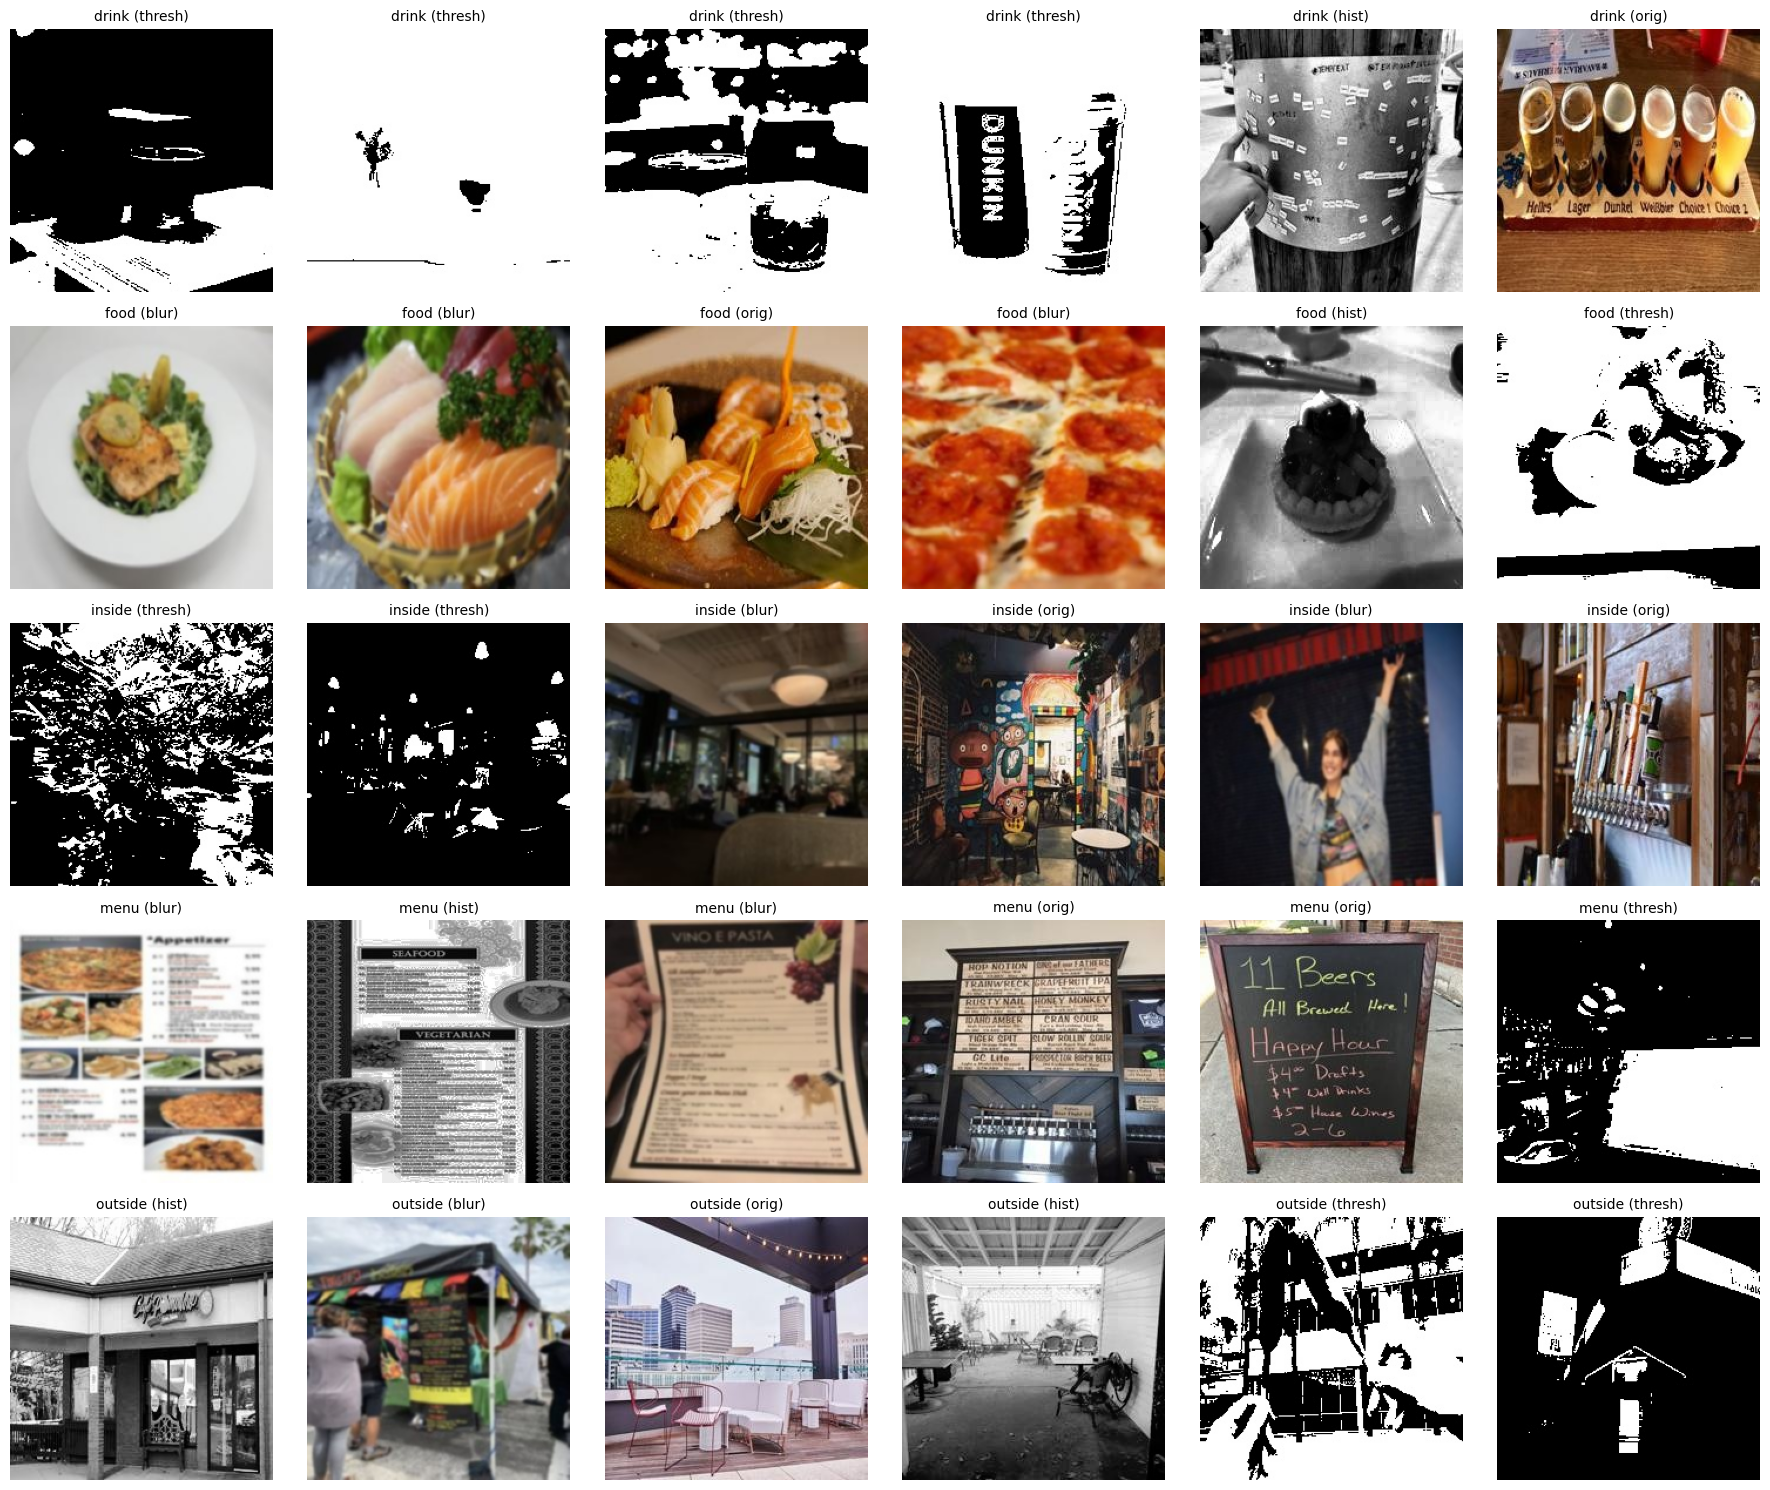

In [38]:
import os
import random
import matplotlib.pyplot as plt
import cv2

base_dir = r'./balanced_photos_5000'

# Only include folders
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
samples_per_class = 6

plt.figure(figsize=(18, len(classes)*3))

for idx, cls in enumerate(classes):
    class_dir = os.path.join(base_dir, cls)
    imgs = [img for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_imgs = random.sample(imgs, samples_per_class)

    for j, img_name in enumerate(selected_imgs):
        img_path = os.path.join(class_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(len(classes), samples_per_class, idx*samples_per_class + j + 1)
        plt.imshow(img)
        plt.axis('off')
        if '_blur' in img_name:
            title = f'{cls} (blur)'
        elif '_hist' in img_name:
            title = f'{cls} (hist)'
        elif '_thresh' in img_name:
            title = f'{cls} (thresh)'
        else:
            title = f'{cls} (orig)'
        plt.title(title, fontsize=10)

plt.tight_layout()
plt.show()

## Class balance after augmentation

Class counts: {'drink': 5000, 'food': 5000, 'inside': 5000, 'menu': 5000, 'outside': 5000}


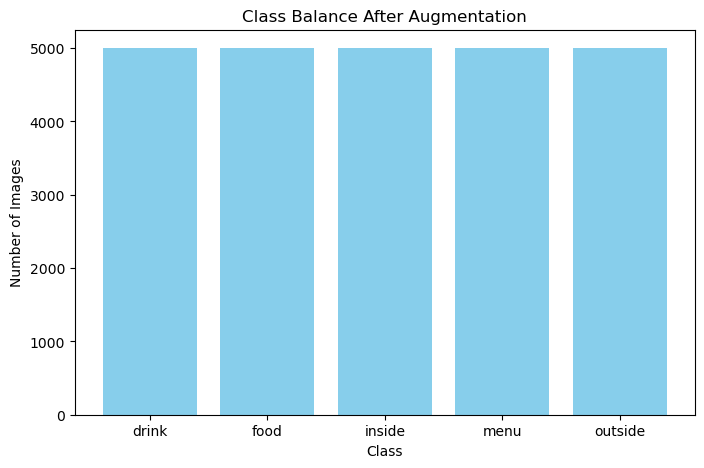

In [41]:
import os
import matplotlib.pyplot as plt

base_dir = r'./balanced_photos_5000'

# Only count actual folders
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
class_counts = {}

for cls in classes:
    class_dir = os.path.join(base_dir, cls)
    imgs = [img for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(imgs)

# Print counts
print("Class counts:", class_counts)

# Bar plot
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Balance After Augmentation')
plt.show()

## Directory to save train-test data

In [45]:
import os

base_dir = r'./balanced_photos_5000'
train_dir = r'./train'
test_dir = r'./test'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Create subfolders for each class
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

## Train - Test (Split 80 - train, 20 - test)

In [49]:
import shutil
import random

split_ratio = 0.8  # 80% train, 20% test

for cls in classes:
    class_dir = os.path.join(base_dir, cls)
    images = [img for img in os.listdir(class_dir) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)
    split_idx = int(len(images) * split_ratio)
    train_imgs = images[:split_idx]
    test_imgs = images[split_idx:]
    # Copy train
    for img in train_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_dir, cls, img))
    # Copy test
    for img in test_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(test_dir, cls, img))

In [51]:
for cls in classes:
    n_train = len(os.listdir(os.path.join(train_dir, cls)))
    n_test = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {n_train} train, {n_test} test")

drink: 4000 train, 1000 test
food: 4000 train, 1000 test
inside: 4000 train, 1000 test
menu: 4000 train, 1000 test
outside: 4000 train, 1000 test


## LLM Prompts
- what is guassian blur, intensity threshold and histogram how to do it.
- how to map meta data to save in csv.
- how to create subfolders